# Classificatore Real+Augmented - ResNet-50

Il notebook implementa un classificatore addestrato su un dataset arricchito attraverso **data augmentation tradizionale**. 

Viene utilizzata l'architettura **ResNet-50** utilizzata nelle altre configurazioni del progetto, riaddestrandola sui dati estesi.

### Composizione dataset
*   **Train set:** Immagini originali reali (classi `0` e `1` da `data/processed/train/`) **+** campioni positivi augmentati tradizionalmente (`data/real_augmented/`).
*   **Validation / Test set:** Sole immagini originali reali (`data/processed/`).

#### Setup percorsi

In [1]:
import os, sys
from pathlib import Path

#rileva colab oppure ambiente locale/WSL e imposta il percorso di MammoDiffusion
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
#cerca 'data/processed' partendo da cartella corrente e se non lo trova usa path personale
else:
    print("ambiente locale/WSL")
    cands = [Path.cwd(), *Path.cwd().parents]
    root = next((p for p in cands if (p / 'data' / 'processed').is_dir()), 
                Path('/mnt/c/Users/samto/Desktop/MammoDiffusion'))
    BASE_PATH = f"{root}/"

print("percorso base:", BASE_PATH)

ambiente locale/WSL
percorso base: /mnt/c/Users/samto/Desktop/MammoDiffusion/


#### Import e Configurazione GPU
- Poiché l'addestramento viene eseguito in locale (WSL) si è rivelato necessario gestire l'utilizzo di VRAM della GPU.
- Di default TensorFlow occupa subito tutta la VRAM disponibile.
- Con l'opzione `memory_growth` TF alloca la memoria in modo incrementale invece che tutta all'avvio. 

In [2]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   #silenzia i log di TensorFlow

import re, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    classification_report, precision_score, recall_score,
    f1_score, accuracy_score
)
tf.get_logger().setLevel('ERROR')          #silenzia warning python

#allocazione dinamica memoria GPU per evitare OOM
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("set_memory_growth:", e)

#### Configurazione
- Definizione iperparametri globali, seed per riproducibilità e le costanti per il preprocessing.
- Viene configurato un meccanismo di fallback per il `batch_size` così da prevenire errori di out-of-memory su GPU.
- Vengono settati i valori di normalizzazione ImageNet necessari per il transfer learning.

In [3]:
SEED = 42                                          
ARCH = "ResNet-50"                                  #nome architettura
IMG_SIZE = (224, 224)                               #dimensioni immagini input come nelle altre configurazioni
BATCH_SIZE = 16                                     
BATCH_SIZE_FALLBACK = 8                             #dimensione batch_size ridotta in caso di OOM
UNFREEZE_FROM = "conv4_block5_1_conv"               #layer partenza sblocco pesi in fase 2
CONFIG = "Real+Augmented"                                 #nome configurazione

IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])  #medie canali RGB dataset ImageNet per normalizzazione
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225])  #deviazioni standard canali RGB dataset ImageNet per normalizzazione
AUTOTUNE = tf.data.AUTOTUNE                         #delega gestione dinamica parallelismo pipeline dati a TensorFlow

OUTPUT_DIR = os.path.join(BASE_PATH, 'experiments', 'exp_trad_aug_resnet50') #path directory output
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')   #path directory grafici
os.makedirs(FIGURES_DIR, exist_ok=True)             

keras.utils.set_random_seed(SEED)                   #applica seed globale al framework

I0000 00:00:1781838337.999216   53648 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1751 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


#### Costruzione dei subset per l'addestramento
- Creazione dei subset (training, validation e test). Solo il training set contiene i campioni positivi augmentati, mentre val e test set utilizzano img reali.
- I tre subset vengono trasformati in pipeline dinamiche tramite `tf.data` così da delegare a TensorFlow il preprocessing.
- Infine vengono calcolati i `class_weights` per sensibilizzare il modello ai casi "malati", che rimangono minoritari.

In [4]:
DIR_TRAIN = os.path.join(BASE_PATH, 'data', 'processed', 'train')   #crea percorso cartella training set
DIR_VAL   = os.path.join(BASE_PATH, 'data', 'processed', 'val')     # ---- validation set
DIR_TEST  = os.path.join(BASE_PATH, 'data', 'processed', 'test')    # ---- test set
DIR_AUG   = os.path.join(BASE_PATH, 'data', 'real_augmented')       # ---- immagini augmentate positive

_LABEL_RE = re.compile(r"_label([01])")                             #REEXP per estrarre classe dal nome file

#carica percorsi e classi per img reali organizzate in sottocartelle
def carica_dati_real(base_dir, classi=("0", "1")):
    paths, labels = [], []
    for c in classi:
        for p in sorted(Path(base_dir).joinpath(c).glob("*.png")):  #cerca e ordina alfabeticamente tutti file png
            paths.append(str(p)); labels.append(int(c))
    return np.array(paths), np.array(labels, dtype=np.int32)

#carica percorsi e classi per img augmentate estraendo etichetta da nome file
def carica_dati_augmented(dirpath):
    paths, labels = [], []
    for p in sorted(Path(dirpath).glob("*.png")):
        m = _LABEL_RE.search(p.name)
        if m is None:
            continue
        paths.append(str(p)); labels.append(int(m.group(1)))
    return np.array(paths), np.array(labels, dtype=np.int32)

#carica array con percorsi reali e augmentati per training set
real_tr_p, real_tr_y = carica_dati_real(DIR_TRAIN)
aug_p, aug_y = carica_dati_augmented(DIR_AUG)
#unisce percorsi e etichette reali e augmentati
train_p = np.concatenate([real_tr_p, aug_p])
train_y = np.concatenate([real_tr_y, aug_y])
#carica array con percorsi e etichette per validazione e test set
val_p, val_y = carica_dati_real(DIR_VAL)
test_p, test_y = carica_dati_real(DIR_TEST)

#stampa conteggio e distribuzione classi per ciascun subset
def count(nome, y):
    print("%-6s tot=%5d | sano(0)=%5d | malato(1)=%5d" % (nome, len(y), int((y==0).sum()), int((y==1).sum())))

print("[Real+Augmented] reali train=%d + augmentati positivi=%d" % (len(real_tr_y), len(aug_y)))
count("TRAIN", train_y); 
count("VAL", val_y); 
count("TEST", test_y)

#preprocessing delle img
def preprocess(path, label):
    #legge e decodifica immagine da disco
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)            #ridimensiona alla dimensione di input
    img = tf.cast(img, tf.float32) / 255.0          #normalizza i valori dei pixel tra 0 e 1
    img = tf.repeat(img, repeats=3, axis=-1)        #duplica il singolo canale sui 3 RGB per compatibilita'
    img = (img - IMAGENET_MEAN) / IMAGENET_STD      #normalizzazione ImageNet
    return img, tf.cast(label, tf.float32)

#costruisce i dataset train/val/test
def crea_dataset(p, y, shuffle=False, batch_size=None):
    #costruisce pipeline dati TF e gestisce eventuale cambio di dimensione batch
    bs = batch_size if batch_size is not None else BATCH_SIZE
    ds = tf.data.Dataset.from_tensor_slices((p, y))
    if shuffle:
        ds = ds.shuffle(len(p), seed=SEED)
    #applica preprocess in parallelo
    ds = ds.map(lambda a, b: preprocess(a, b), num_parallel_calls=AUTOTUNE)
    return ds.batch(bs).prefetch(AUTOTUNE) #evita che la GPU rimanga in attesa della CPU durante l'addestramento

train_ds = crea_dataset(train_p, train_y, shuffle=True)   #crea pipeline per addestramento con shuffle  
#crea pipeline per validazione e test senza mescolamento
val_ds = crea_dataset(val_p, val_y, shuffle=False)
test_ds = crea_dataset(test_p, test_y, shuffle=False)

#calcola pesi bilanciamento per classi rare
_classes = np.unique(train_y)
_w = compute_class_weight("balanced", classes=_classes, y=train_y)
class_weight_dict = dict(zip(_classes.astype(int), _w))
print("class weights:", class_weight_dict)

[Real+Augmented] reali train=2041 + augmentati positivi=1020
TRAIN  tot= 3061 | sano(0)= 1701 | malato(1)= 1360
VAL    tot=  437 | sano(0)=  364 | malato(1)=   73
TEST   tot=  438 | sano(0)=  365 | malato(1)=   73
class weights: {np.int64(0): np.float64(0.8997648442092887), np.int64(1): np.float64(1.1253676470588236)}


#### Architettura ResNet-50
- Definizione della backbone `ResNet-50` utilizzata nelle altre configurazioni dei classificatori.
- La rete pre-addestrata su ImageNet viene congelata e le viene aggiunta una nuova testa di classificazione customizzata.

In [5]:
#crea istanza del modello
def build_model():
    #carica il modello ResNet50 pre-addestrato su ImageNet senza livelli fully connected
    base_model = keras.applications.ResNet50(
        weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,)
    )
    base_model.trainable = False                       #congela pesi backbone per la fase 1 di addestramento
    inputs = keras.Input(shape=IMG_SIZE + (3,))        #input layer
    x = base_model(inputs, training=False)             #passa input a backbone con BatchNormalization in mod inferenza
    x = layers.GlobalAveragePooling2D()(x)             #si applica global pooling 2D
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x) #livello dense con 256 neuroni e regolarizzazione L2
    x = layers.BatchNormalization()(x)                 #BatchNormalization per stabilizzare attivazioni
    x = layers.LeakyReLU(negative_slope=0.1)(x)        #funzione attivazione
    x = layers.Dropout(0.5)(x)                         #dropout per evitare overfitting
    outputs = layers.Dense(1, activation='sigmoid')(x) #output layer per classificazione binaria
    return keras.Model(inputs, outputs), base_model    #restituisce modello completo e riferimento alla backbone

model, base_model = build_model()                      #crea modello e backbone
model.summary()                                        #stampa riepilogo architettura

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,537 (91.99 MB)

 Trainable params: 525,313 (2.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

#### Training in 2 fasi
L'addestramento è strutturato in due fasi per svolgere il Transfer Learning:
- **Fase 1** - La backbone pre-addestrata viene tenuta congelata e si addestra solo la testa del modello con `binary_crossentropy`. Il congelamento dei pesi della backbone evita che i gradienti iniziali alti (testa parte da pesi casuali) annullino i pesi pre-esistenti della rete.
- **Fase 2** - Si sblocca la parte finale della backbone dal layer `conv4_block5_1_conv` in poi, tenendo congelati i layers di `BatchNormalization` per avere stabilità statistica. Si utilizza un learning rate basso e la `BinaryFocalCrossentropy` che forza il modello a concentrarsi sui casi più difficili.

La procedura è posta in una funzione interrompre l'addestramento e lo riavvia con diverso `batch_size` se la VRAM della GPU si satura.

In [6]:
#incapsula training in due fasi per cambiare batch_size in caso di OOM su GPU
def esegui_training(bs):
    keras.utils.set_random_seed(SEED)   #seed indipendente dal batch size
    #crea pipeline con il batch richiesto
    train_ds = crea_dataset(train_p, train_y, shuffle=True,  batch_size=bs)
    val_ds   = crea_dataset(val_p,   val_y,   shuffle=False, batch_size=bs)
    model, base_model = build_model()   #istanza modello e backbone

    #compila il modello per la fase 1 usando binary crossentropy
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Recall(name='recall'), keras.metrics.Precision(name='precision')]
    )

    #callback per fase 1 con early stopping e salvataggio
    cb1 = [
        keras.callbacks.EarlyStopping(monitor='val_auc', patience=7, restore_best_weights=True, mode='max'),
        keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, 'trad_aug_resnet50_fase1_best.keras'), monitor='val_auc', save_best_only=True, mode='max'),
        keras.callbacks.CSVLogger(os.path.join(OUTPUT_DIR, 'training_log_fase1.csv'), append=False),
    ]

    #addestramento fase 1 applicando i class_weight
    h1 = model.fit(train_ds, epochs=25, validation_data=val_ds, class_weight=class_weight_dict, callbacks=cb1)

    #sblocca backbone per fine-tuning partendo dal layer specificato
    base_model.trainable = True
    set_trainable = False
    #sblocca la parte finale della backbone come nelle altre configurazioni
    for layer in base_model.layers:
        if layer.name == UNFREEZE_FROM:         
            set_trainable = True
        layer.trainable = set_trainable
    #mantiene congelati i BatchNormalization per stabilita
    for layer in base_model.layers:             
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    #stampa numero livelli addestrabili per debug
    print("layer base_model addestrabili:",
          sum(1 for l in base_model.layers if l.trainable), "/", len(base_model.layers))

    #compila il modello per fase 2 diminuendo il learning rate e impostando focal loss
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss=keras.losses.BinaryFocalCrossentropy(apply_class_balancing=True, alpha=0.75, gamma=2.0, from_logits=False),
        metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Recall(name='recall'), keras.metrics.Precision(name='precision')]
    )

    #definisce callback per la fase 2 aggiungendo ReduceLROnPlateau per il learning rate
    cb2 = [
        keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, min_delta=1e-3, restore_best_weights=True, mode='max'),
        keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, 'trad_aug_resnet50_final_best.keras'), monitor='val_auc', save_best_only=True, mode='max'),
        keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, mode='max', min_lr=1e-7),
        keras.callbacks.CSVLogger(os.path.join(OUTPUT_DIR, 'training_log_fase2.csv'), append=False),
    ]

    #avvia addestramento fase 2 senza class_weights perche bilanciati da focal loss
    h2 = model.fit(train_ds, epochs=30, validation_data=val_ds, callbacks=cb2)
    return model, base_model, h1, h2

#tenta addestramento con batch principale e utilizza fallback se GPU lancia eccezione
try:
    print("training a batch:", BATCH_SIZE)
    model, base_model, history_phase1, history_phase2 = esegui_training(BATCH_SIZE)
    batch_effettivo = BATCH_SIZE
except tf.errors.ResourceExhaustedError:
    print("OOM a batch", BATCH_SIZE, "- diminuisce batch_size:", BATCH_SIZE_FALLBACK)
    #svuota la memoria VRAM prima del secondo tentativo
    keras.backend.clear_session()
    model, base_model, history_phase1, history_phase2 = esegui_training(BATCH_SIZE_FALLBACK)
    batch_effettivo = BATCH_SIZE_FALLBACK

print("\nbatch_size utilizzato:", batch_effettivo)

#ricostruisce i dataset val e test con il batch effettivo per uniformare la valutazione
val_ds  = crea_dataset(val_p,  val_y,  shuffle=False, batch_size=batch_effettivo)
test_ds = crea_dataset(test_p, test_y, shuffle=False, batch_size=batch_effettivo)

training a batch: 16
Epoch 1/25


I0000 00:00:1781838375.501032   53840 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


192/192 ━━━━━━━━━━━━━━━━━━━━ 61s 185ms/step - accuracy: 0.5795 - auc: 0.6039 - loss: 0.8089 - precision: 0.5241 - recall: 0.5838 - val_accuracy: 0.6201 - val_auc: 0.6065 - val_loss: 0.6789 - val_precision: 0.2281 - val_recall: 0.5342
Epoch 2/25
192/192 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - accuracy: 0.6348 - auc: 0.6934 - loss: 0.6861 - precision: 0.5781 - recall: 0.6588 - val_accuracy: 0.6545 - val_auc: 0.6179 - val_loss: 0.6299 - val_precision: 0.2254 - val_recall: 0.4384
Epoch 3/25
192/192 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - accuracy: 0.6664 - auc: 0.7336 - loss: 0.6552 - precision: 0.6143 - recall: 0.6699 - val_accuracy: 0.7460 - val_auc: 0.6209 - val_loss: 0.5681 - val_precision: 0.2683 - val_recall: 0.3014
Epoch 4/25
192/192 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.7063 - auc: 0.7726 - loss: 0.6129 - precision: 0.6589 - recall: 0.7029 - val_accuracy: 0.7140 - val_auc: 0.6149 - val_loss: 0.5932 - val_precision: 0.2347 - val_recall: 0.3151
Epoch 5/25
192/192 ━━━━━━━━━━━━━━━

#### Curve di training
- Visualizzazione dell'andamento delle metriche Loss ed AUC durante le due fasi di addestramento.
- Si valuta l'efficacia del fine-tuning.

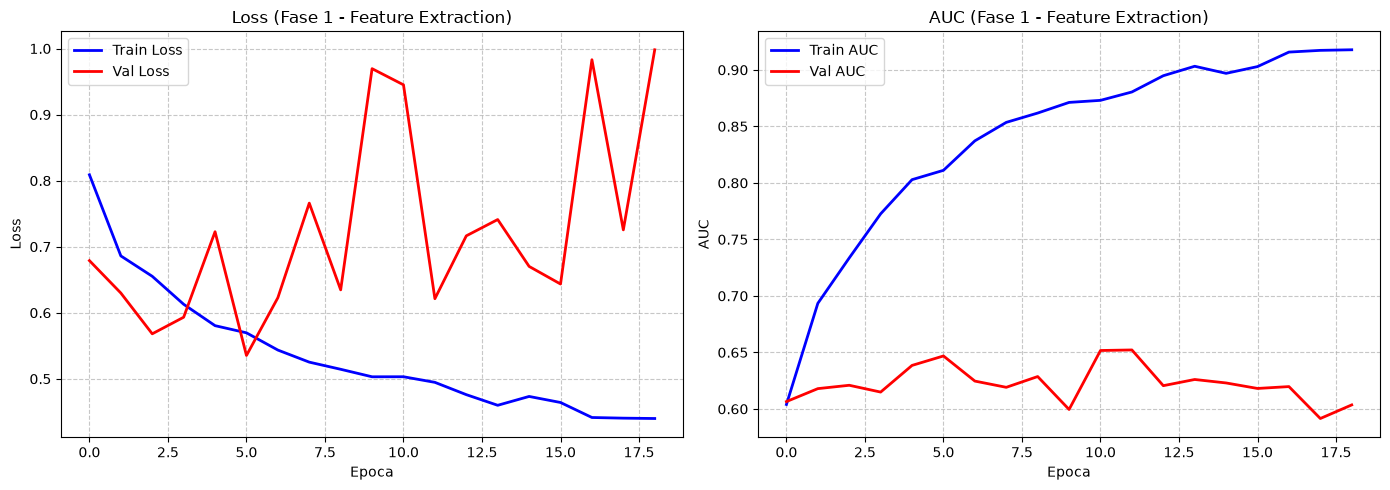

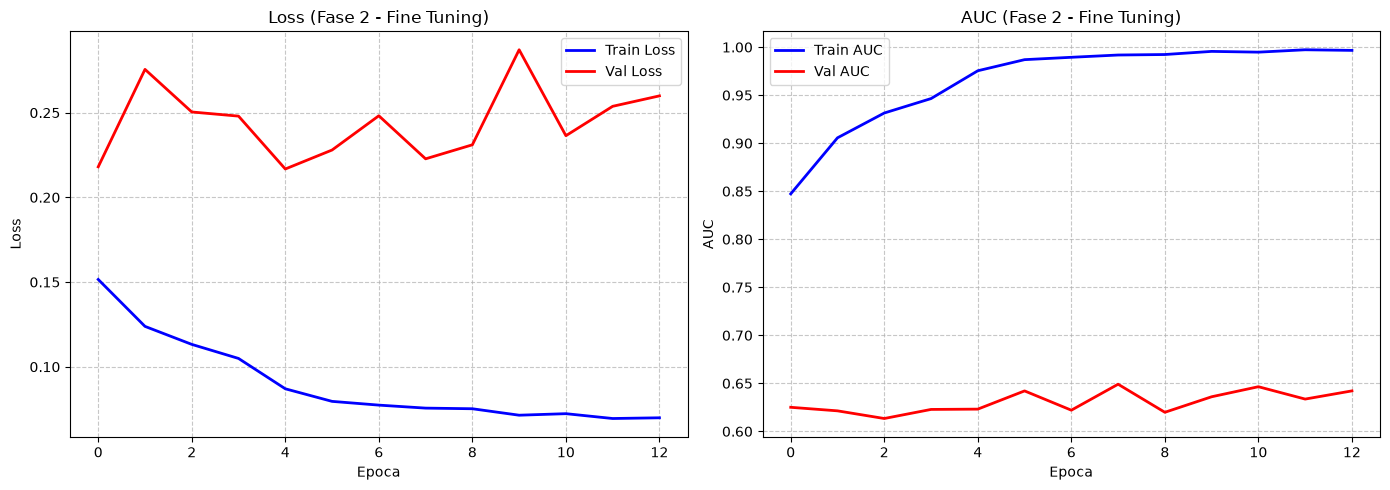

In [7]:
#plotta i grafici di addestramento
def plot_training_history(history, title_suffix="", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    #curve di loss per il training e il validation set
    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title('Loss ' + title_suffix); ax1.set_xlabel('Epoca'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.7)
    
    #curve metrica AUC
    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set_title('AUC ' + title_suffix); ax2.set_xlabel('Epoca'); ax2.set_ylabel('AUC')
    ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

#genera e salva grafico fase 1 e 2
plot_training_history(history_phase1, "(Fase 1 - Feature Extraction)", os.path.join(FIGURES_DIR, 'training_history_fase1_resnet50.png'))
plot_training_history(history_phase2, "(Fase 2 - Fine Tuning)", os.path.join(FIGURES_DIR, 'training_history_fase2_resnet50.png'))

#### Valutazione sul Test Set
- Inferenza e valutazione finale del modello. 
- Per evitare data leakage, la soglia di Youden viene calcolata esclusivamente sulle previsioni del validation set. 
- Questa soglia viene poi congelata e applicata in modo imparziale alle probabilità prodotte sul test set.

soglia di Youden (VAL): 0.4275
AUC (test): 0.5542
              precision    recall  f1-score   support

        Sano       0.85      0.56      0.67       365
      Malato       0.19      0.51      0.27        73

    accuracy                           0.55       438
   macro avg       0.52      0.53      0.47       438
weighted avg       0.74      0.55      0.61       438

metriche salvate in test_metrics_resnet50.json


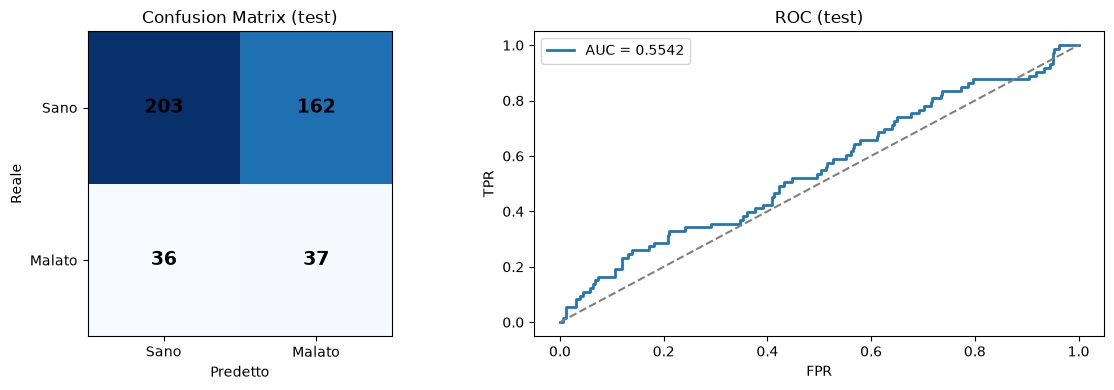

In [8]:
#carica il miglior modello addestrato in fase 2 per l'inferenza
best_model = keras.models.load_model(os.path.join(OUTPUT_DIR, 'trad_aug_resnet50_final_best.keras'), compile=False)

#estrae probabilità ed etichette dei casi reali da ciascun batch per volta
def predici(ds):
    yt, yp = [], []
    for imgs, labels in ds:
        yp.extend(best_model.predict(imgs, verbose=0).flatten())
        yt.extend(labels.numpy())
    return np.array(yt), np.array(yp)

#calcola soglia di Youden ottimizzata sul validation set
val_true, val_prob = predici(val_ds)
fpr_v, tpr_v, thr_v = roc_curve(val_true, val_prob)
best_threshold = float(thr_v[np.argmax(tpr_v - fpr_v)])
print("soglia di Youden (VAL):", round(best_threshold, 4))

#esegue inferenza sul test set e applica la soglia calcolata dal validation
test_true, test_prob = predici(test_ds)
test_pred = (test_prob >= best_threshold).astype(int)

#calcola e stampa metriche finali sul test set
auc = roc_auc_score(test_true, test_prob)
report = classification_report(test_true, test_pred, target_names=['Sano', 'Malato'])
print("AUC (test):", round(float(auc), 4))
print(report)

#salva il dizionario completo delle metriche su disco in formato JSON
metrics_dict = {
    'arch': ARCH, 'config': CONFIG, 'split': 'test',
    'threshold_youden_from_val': round(best_threshold, 4),
    'roc_auc': round(float(auc), 4),
    'accuracy': round(float(accuracy_score(test_true, test_pred)), 4),
    'precision_malato': round(float(precision_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'recall_malato': round(float(recall_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'f1_malato': round(float(f1_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report,
}
with open(os.path.join(OUTPUT_DIR, 'test_metrics_resnet50.json'), 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print("metriche salvate in test_metrics_resnet50.json")

#genera e salva i grafici per confusion matrix sul test set
cm = confusion_matrix(test_true, test_pred)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(cm, cmap='Blues')
ax[0].set_xticks([0, 1]); ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Sano', 'Malato']); ax[0].set_yticklabels(['Sano', 'Malato'])
ax[0].set_xlabel('Predetto'); ax[0].set_ylabel('Reale'); ax[0].set_title('Confusion Matrix (test)')
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')
        
#genera e salva i grafici per curva ROC sul test set
fpr_t, tpr_t, _ = roc_curve(test_true, test_prob)
ax[1].plot(fpr_t, tpr_t, lw=2, label='AUC = %.4f' % auc)
ax[1].plot([0, 1], [0, 1], '--', color='gray')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('ROC (test)'); ax[1].legend()

#stampa plot
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'test_confusion_roc_resnet50.png'), dpi=150, bbox_inches='tight')
plt.show()

#### Valutazione con bootstrap
- Il test set è sbilanciato (365 sani / 73 malati), il che rende inaffidabili metriche come l'accuracy.
- Si implementa un bootstrap bilanciato che ad ogni round ricampiona con reinserimento un numero uguale di casi positivi (malati) e negativi (sani), pari al numero di osservazioni della classe minoritaria.
- Il processo si ripete per `N` round, ottenendo media e deviazione standard di ogni metrica. 
- Il reinserimento limita l'effetto delle classi rare sul calcolo delle metriche.

Accuracy   0.5331 +/- 0.0405
Precision  0.5348 +/- 0.0430
Recall     0.5097 +/- 0.0588
F1         0.5210 +/- 0.0470
ROC_AUC    0.5553 +/- 0.0474


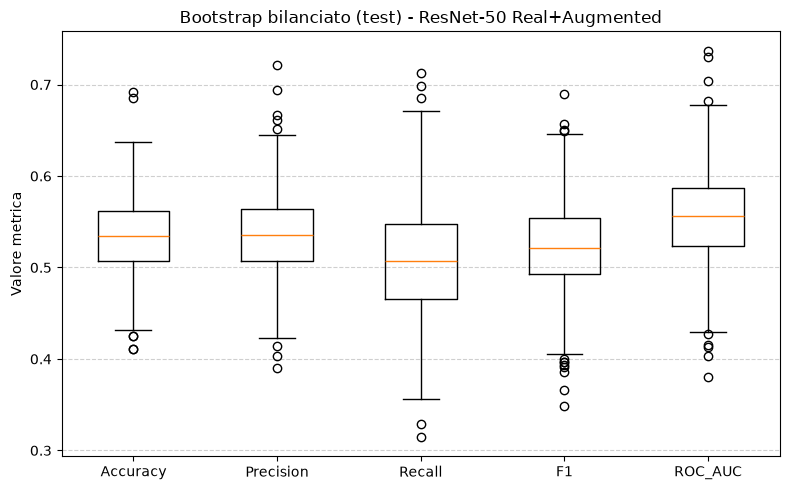

In [9]:
#calcola metriche tramite bootstrap per compensare lo sbilanciamento tra classi
def bootstrap_bilanciato(y_true, y_prob, threshold, n_rounds=1000, seed=SEED):
    rng = np.random.default_rng(seed)       #inizializza generatore numeri casuali
    #seleziona indici dei casi positivi e negativi
    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n = min(len(pos_idx), len(neg_idx))     #dimensione per classe = classe minoritaria 
    out = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': [], 'ROC_AUC': []}      #inizializza dizionario per memorizzare i risultati di ogni round
    
    #ciclo di bootstrap per il numero di round
    for _ in range(n_rounds):
        #ricampiona con reinserimento i positivi ed i negativi
        sel_pos = rng.choice(pos_idx, size=n, replace=True)
        sel_neg = rng.choice(neg_idx, size=n, replace=True)
        #unisce gli indici positivi e negativi ricampionati
        idx = np.concatenate([sel_pos, sel_neg])                
        yt, yp = y_true[idx], y_prob[idx]
        pred = (yp >= threshold).astype(int)     #calcola predizioni basate sulla soglia di Youden
        
        #aggiorna liste dei risultati con metriche calcolate
        out['Accuracy'].append(accuracy_score(yt, pred))
        out['Precision'].append(precision_score(yt, pred, pos_label=1, zero_division=0))
        out['Recall'].append(recall_score(yt, pred, pos_label=1, zero_division=0))
        out['F1'].append(f1_score(yt, pred, pos_label=1, zero_division=0))
        out['ROC_AUC'].append(roc_auc_score(yt, yp))
        
    #stampa media e deviazione standard per ogni metrica
    for k, v in out.items():
        print("%-10s %.4f +/- %.4f" % (k, np.mean(v), np.std(v)))
    return out

#lancia procedura di bootstrap e stampa risultati
boot = bootstrap_bilanciato(test_true, test_prob, best_threshold, n_rounds=1000)

#genera boxplot per visualizzare distribuzione delle metriche
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(list(boot.values()))
ax.set_xticklabels(list(boot.keys()))
ax.set_title('Bootstrap bilanciato (test) - ResNet-50 Real+Augmented')
ax.set_ylabel('Valore metrica'); ax.grid(True, axis='y', linestyle='--', alpha=0.6)
#salva grafico e mostra risultati
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'bootstrap_resnet50.png'), dpi=150, bbox_inches='tight')
plt.show()

#### Salvataggio del modello addestrato

In [10]:
MODEL_PATH = os.path.join(OUTPUT_DIR, 'trad_aug_resnet50_final_best.keras')     #percorso del modello salvato
assert os.path.isfile(MODEL_PATH), f"modello non trovato: {MODEL_PATH}"     #verifica esistenza file prima di procedere
print("modello salvato in:", MODEL_PATH, "(%.1f MB)" % (os.path.getsize(MODEL_PATH) / (1024 ** 2)))     #stampa percorso e dimensione in MB

modello salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/experiments/exp_trad_aug_resnet50/trad_aug_resnet50_final_best.keras (227.8 MB)
